# Machine Learning - Neural Networks



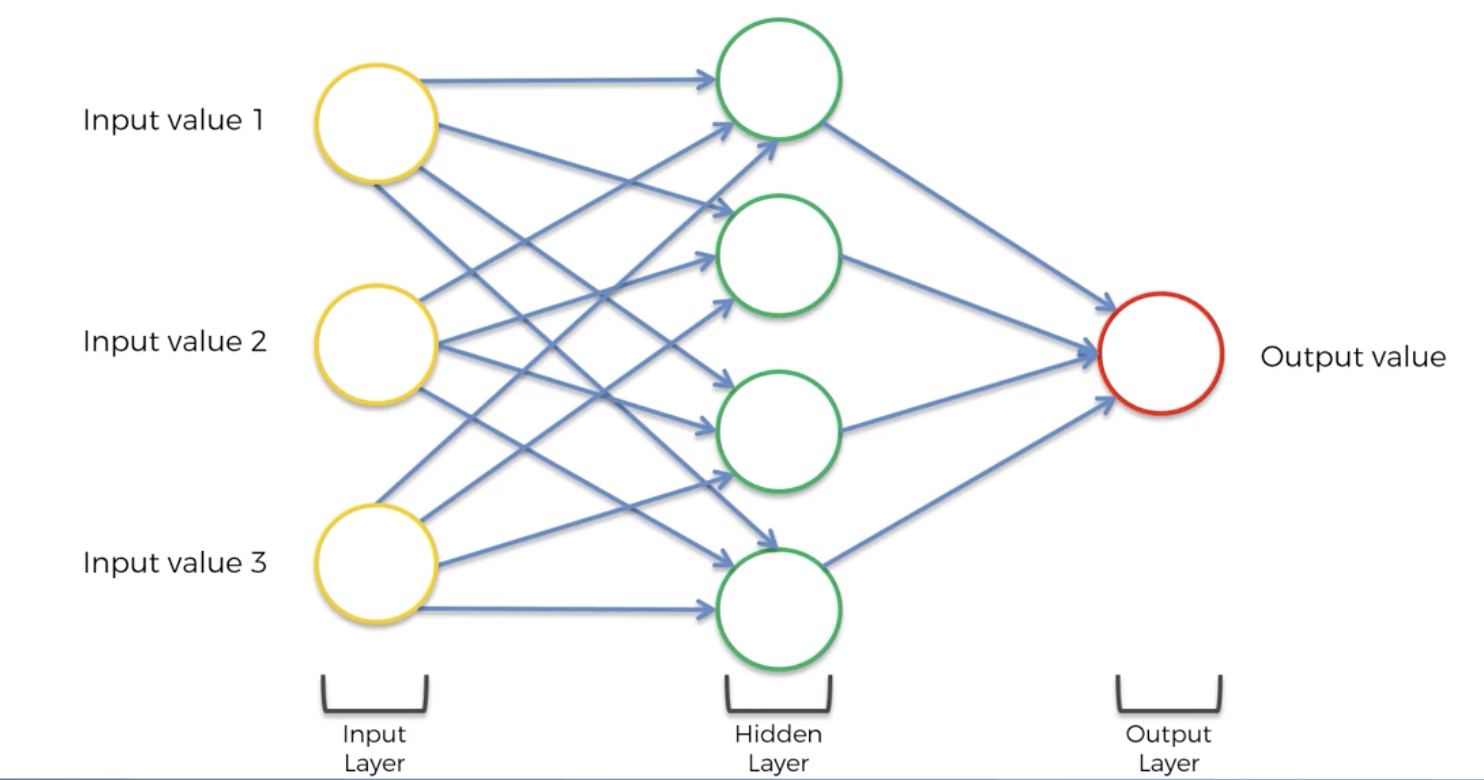

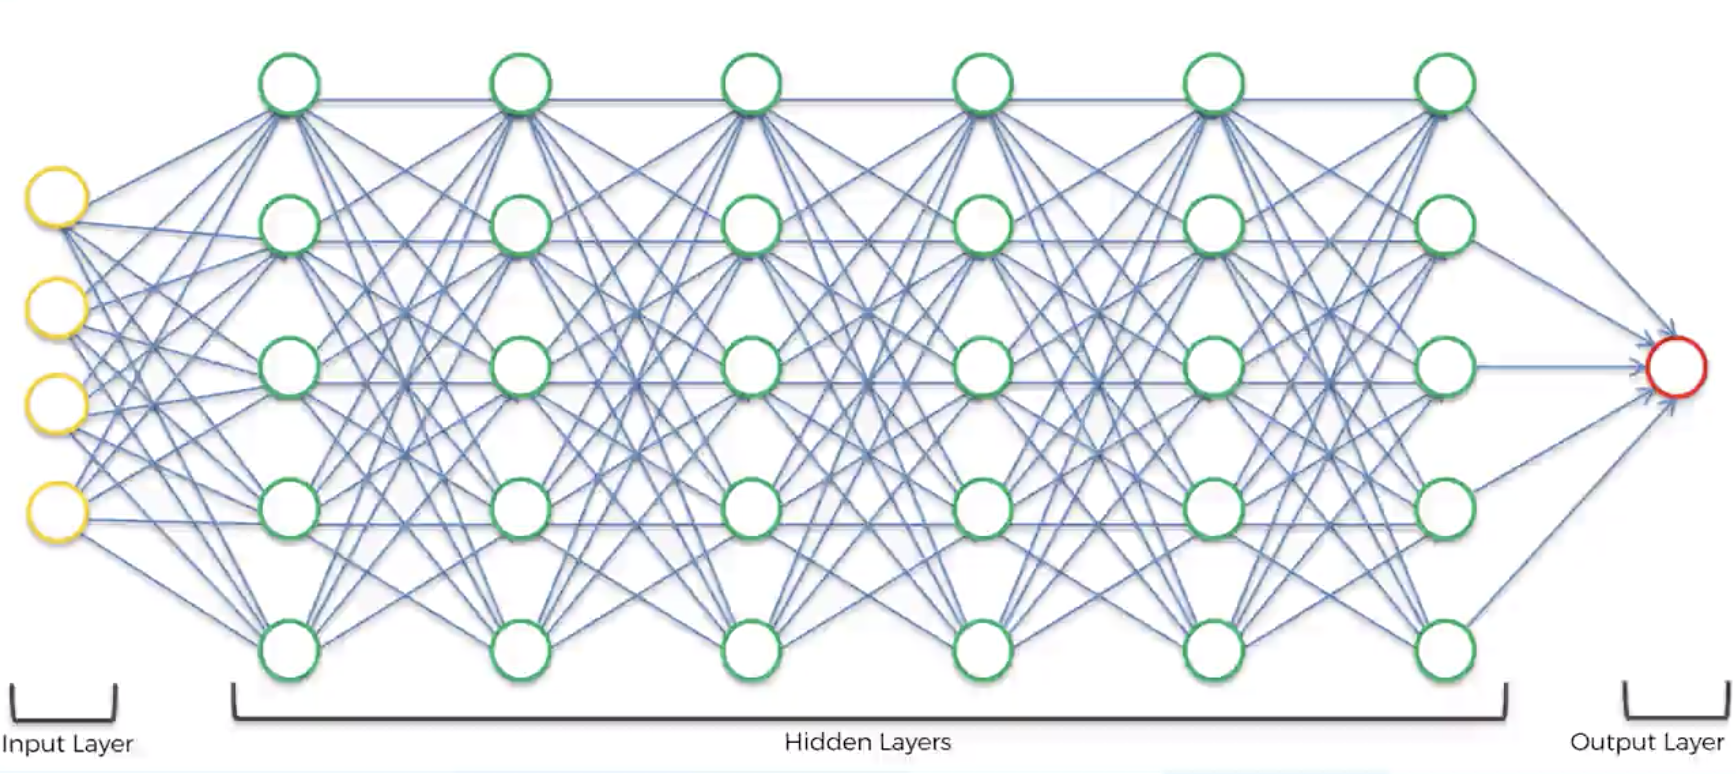


In this part you will learn:

- The Intuition of ANNs

- How to build an ANN

- How to predict the outcome of a single observation (Homework Challenge)

- How to evaluate the performance of an ANN with k-Fold Cross Validation

- How to tackle overfitting with Dropout

- How to do some Parameter Tuning on your ANN to improve its performance


# The Neuron

Each indipendent variables is one for each observation. 

A simple way to understand the role of the bias is considering the constant b of a linear function

$y = ax + b$

It allows you to move the line up and down to fit the prediction with the data better.

Without b, the line always goes through the origin (0, 0) and you may get a poorer fit.

**BIAS ZERO VS BIASED NEURON**<br>
<img src="images/bias_zero.webp" width=49%/>
<img src="images/bias_value.webp" width="49%"/>


# The Activation Function

Here below, we present 4 different types of activation function. 

## Threshold function
is a yes/no type of function. 

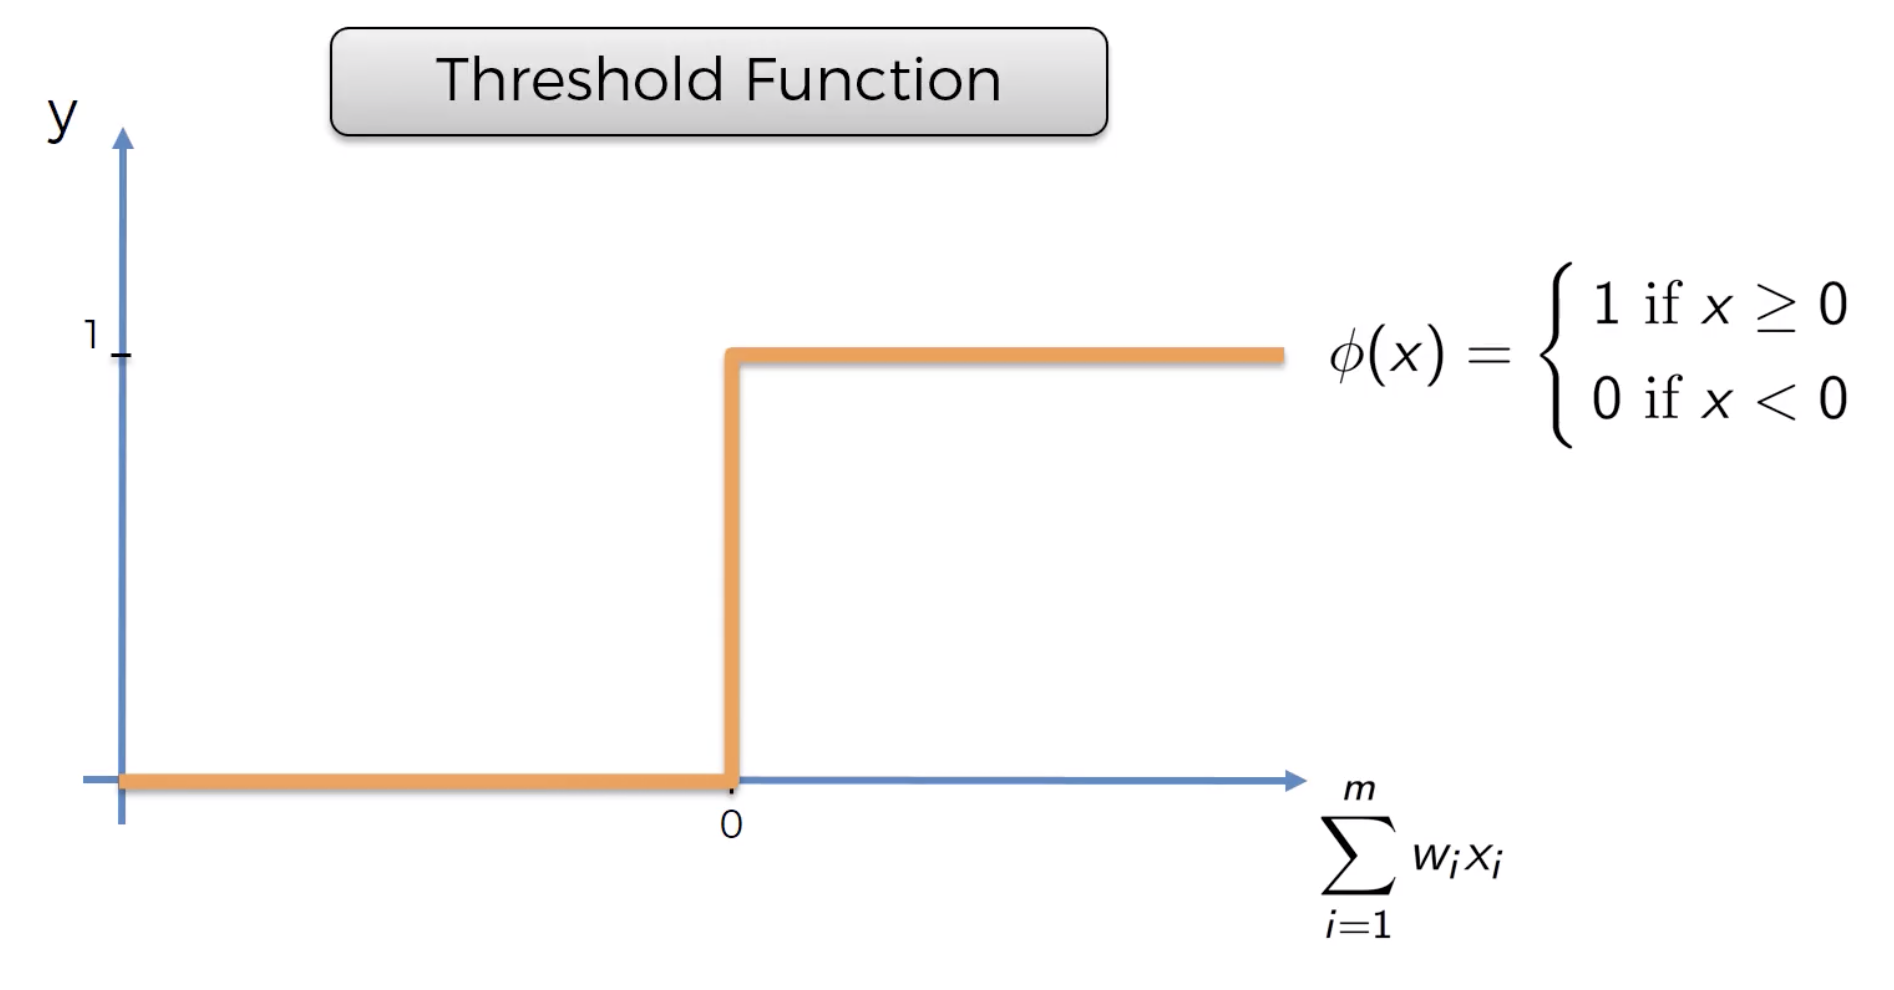


## Sigmoid function 

Is used for the probability of a class.

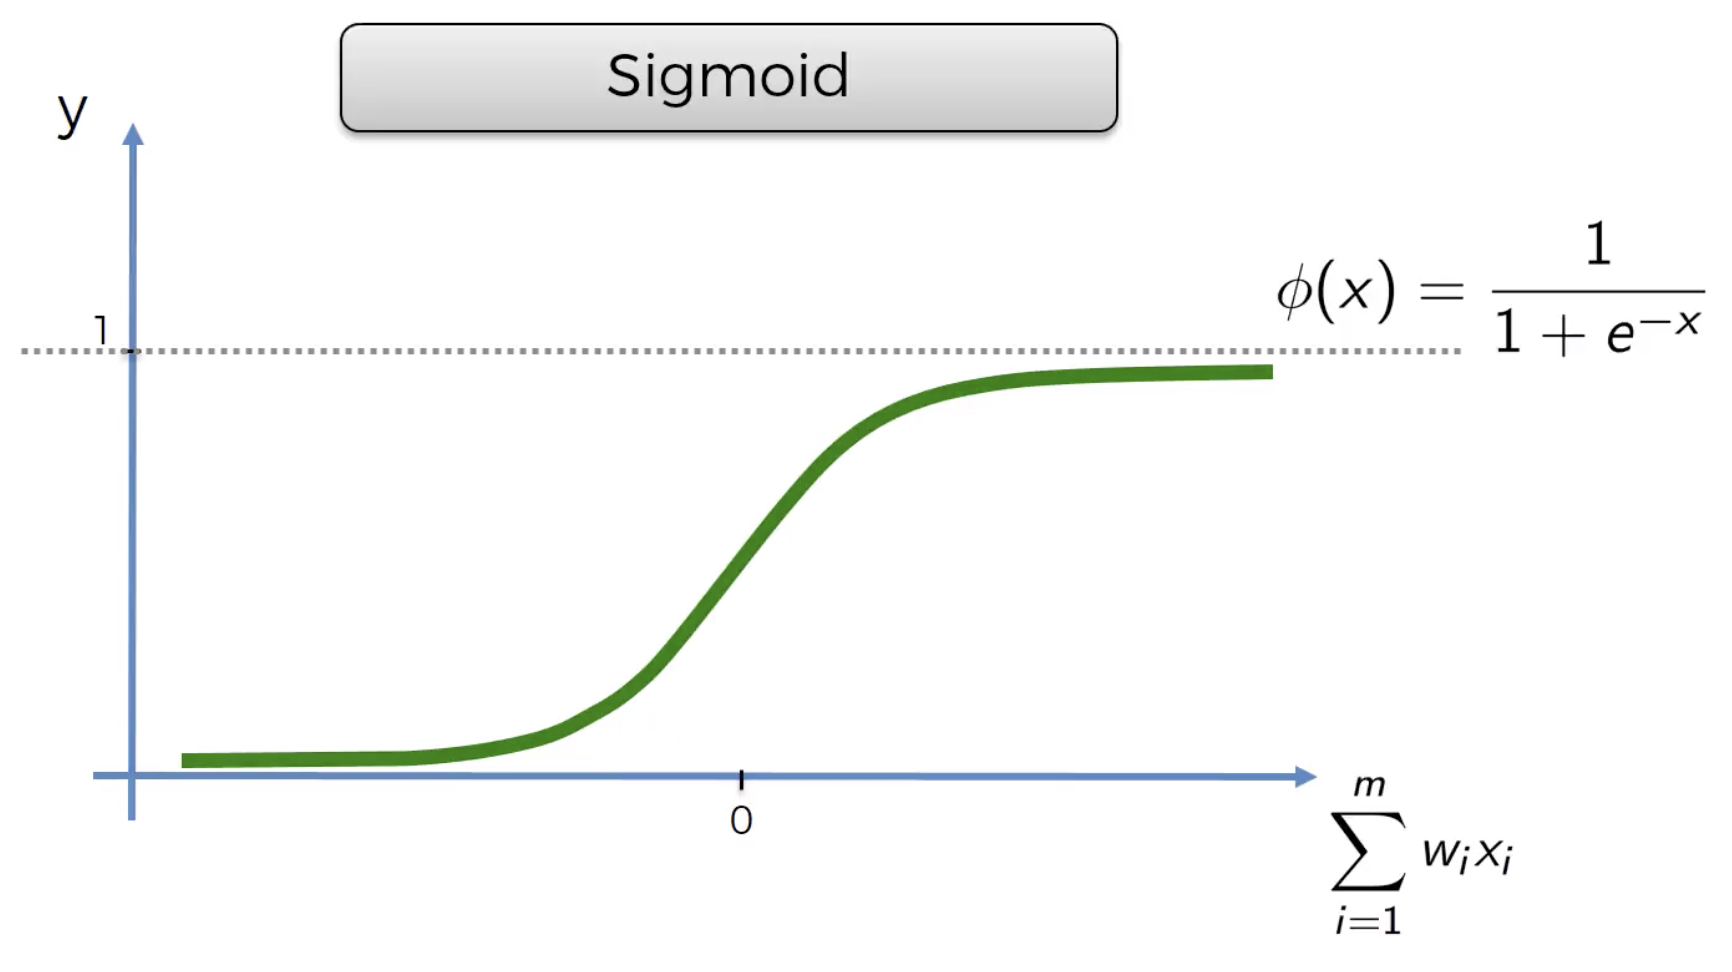


## Rectifier function 

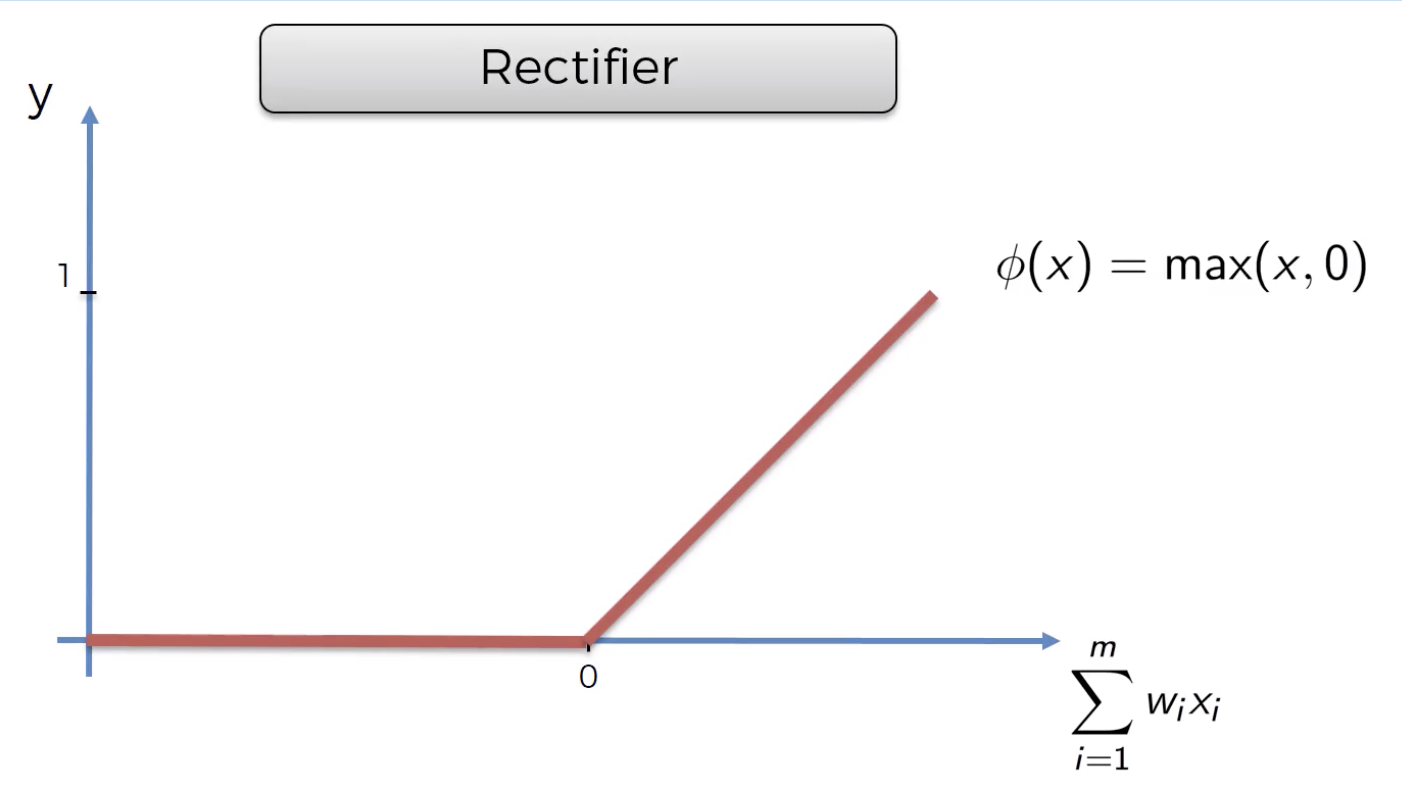


## Hyperbolic Tangent (tanh)


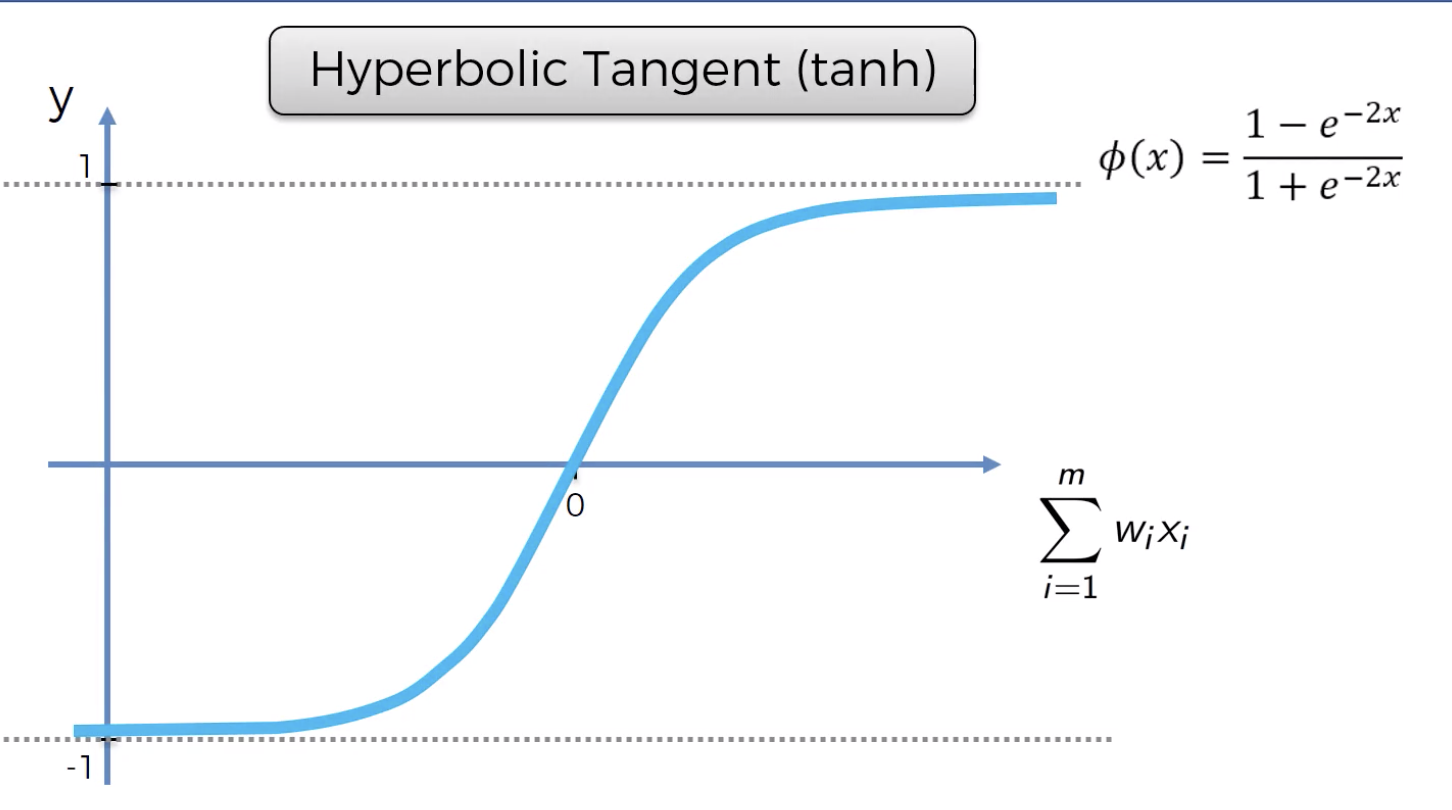


Assuming the output is binary (0 or 1) which kind of activation function you would use? 

# How do Neural Networks work? 

We want to see a previous example. How much does cost an house? 
It is a Regression problem.

Input parameters: 
- Area 
- Bedrooms 
- Distance to city 
- Age


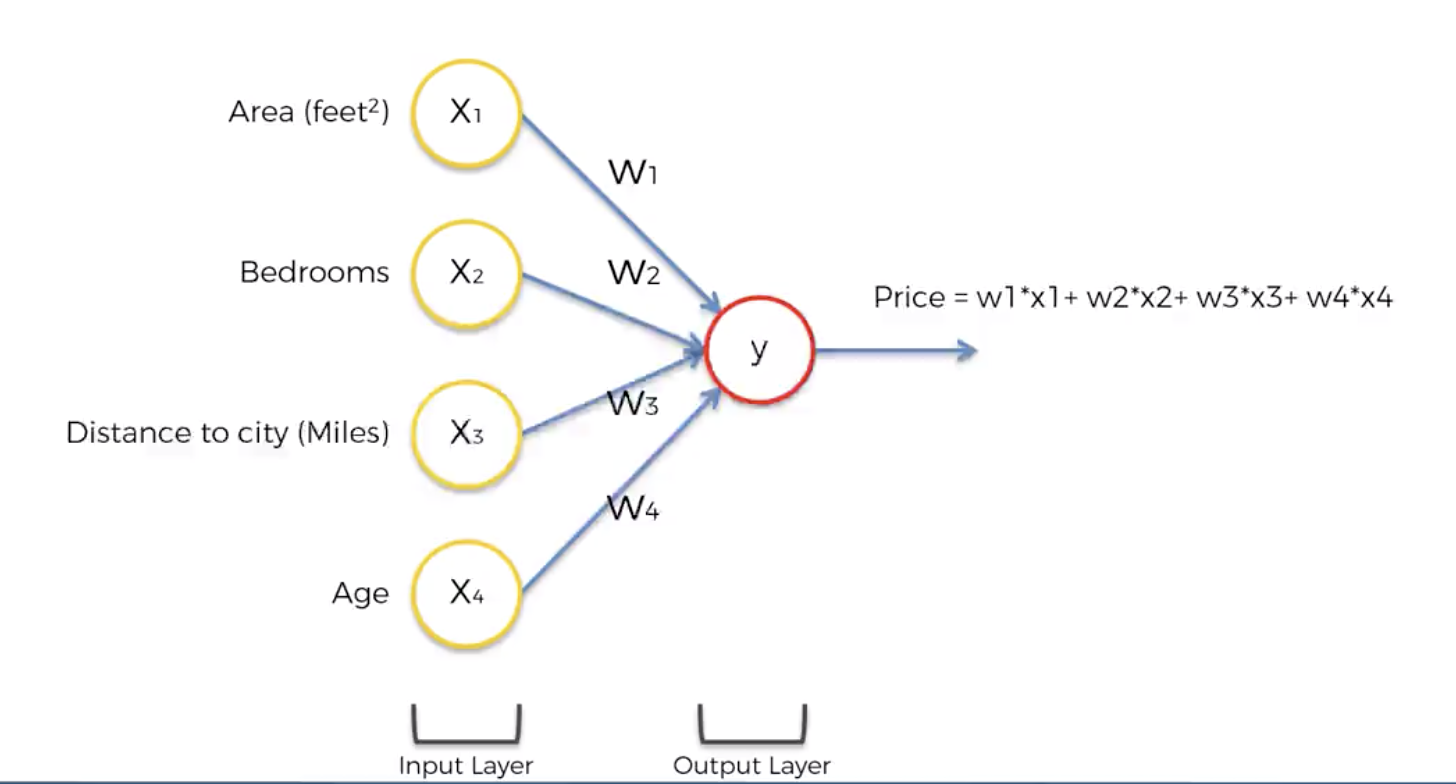


The strenght of the neural network is to combine the parameters in order to collect useful informations for the aim, the regression for example. 


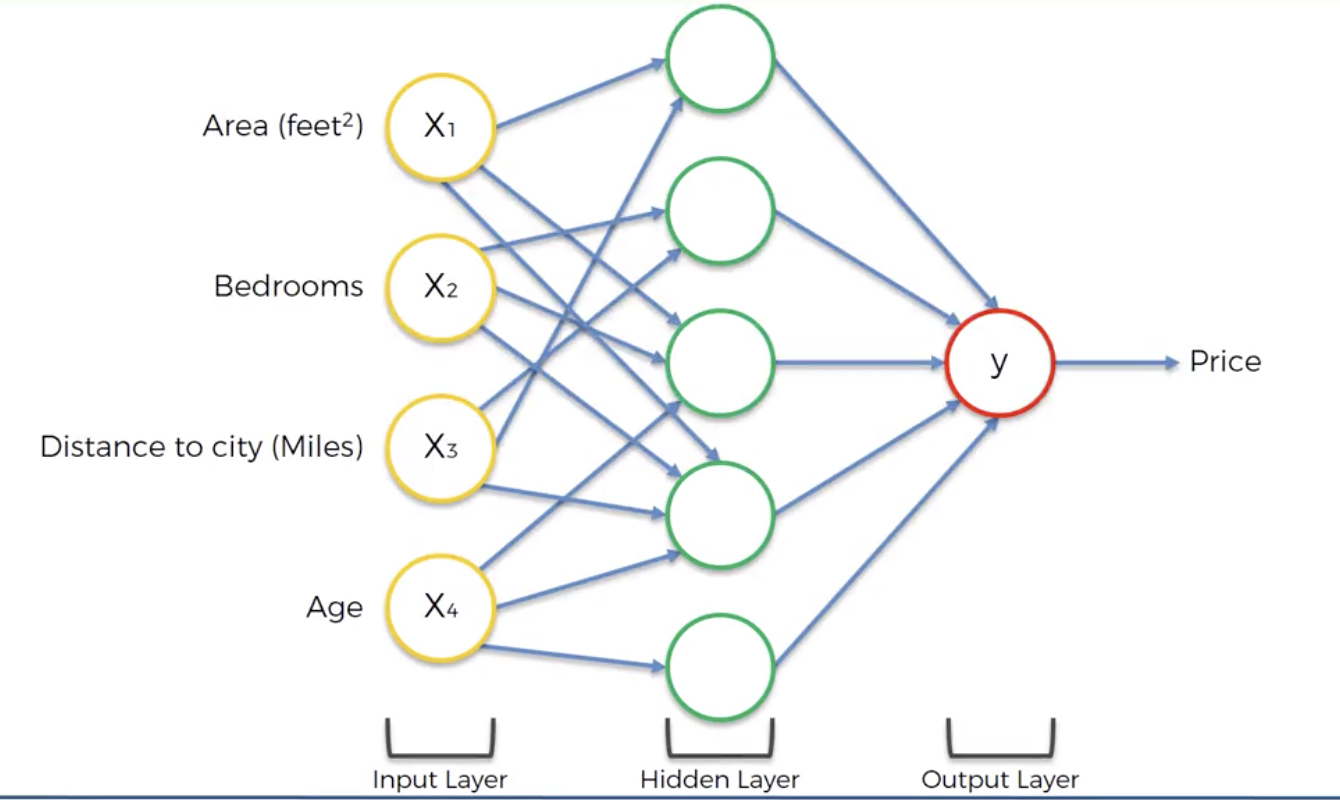




# How do Neural Networks learn? 

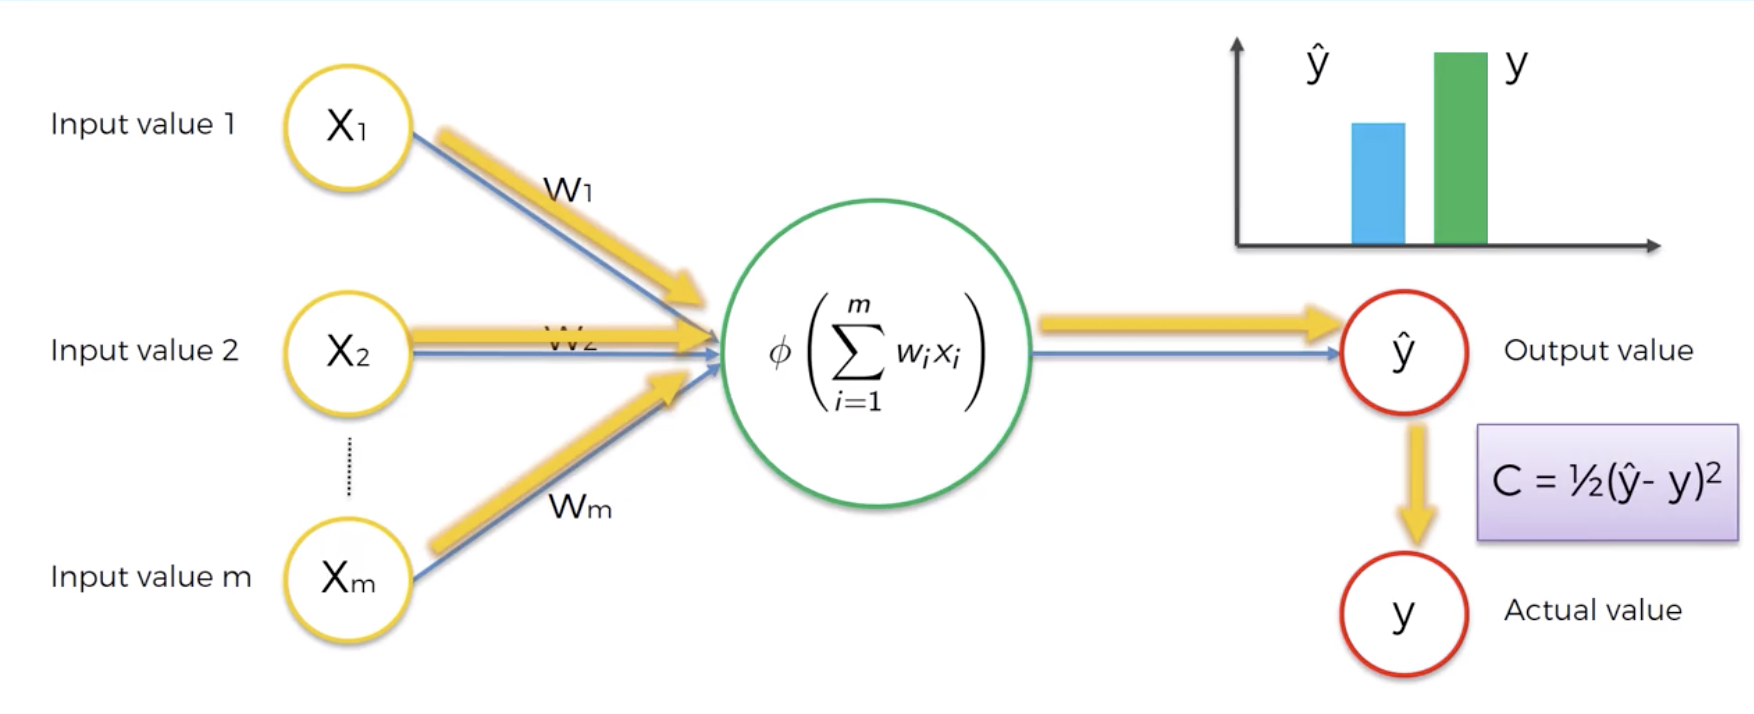


All we can do is update the weights. 

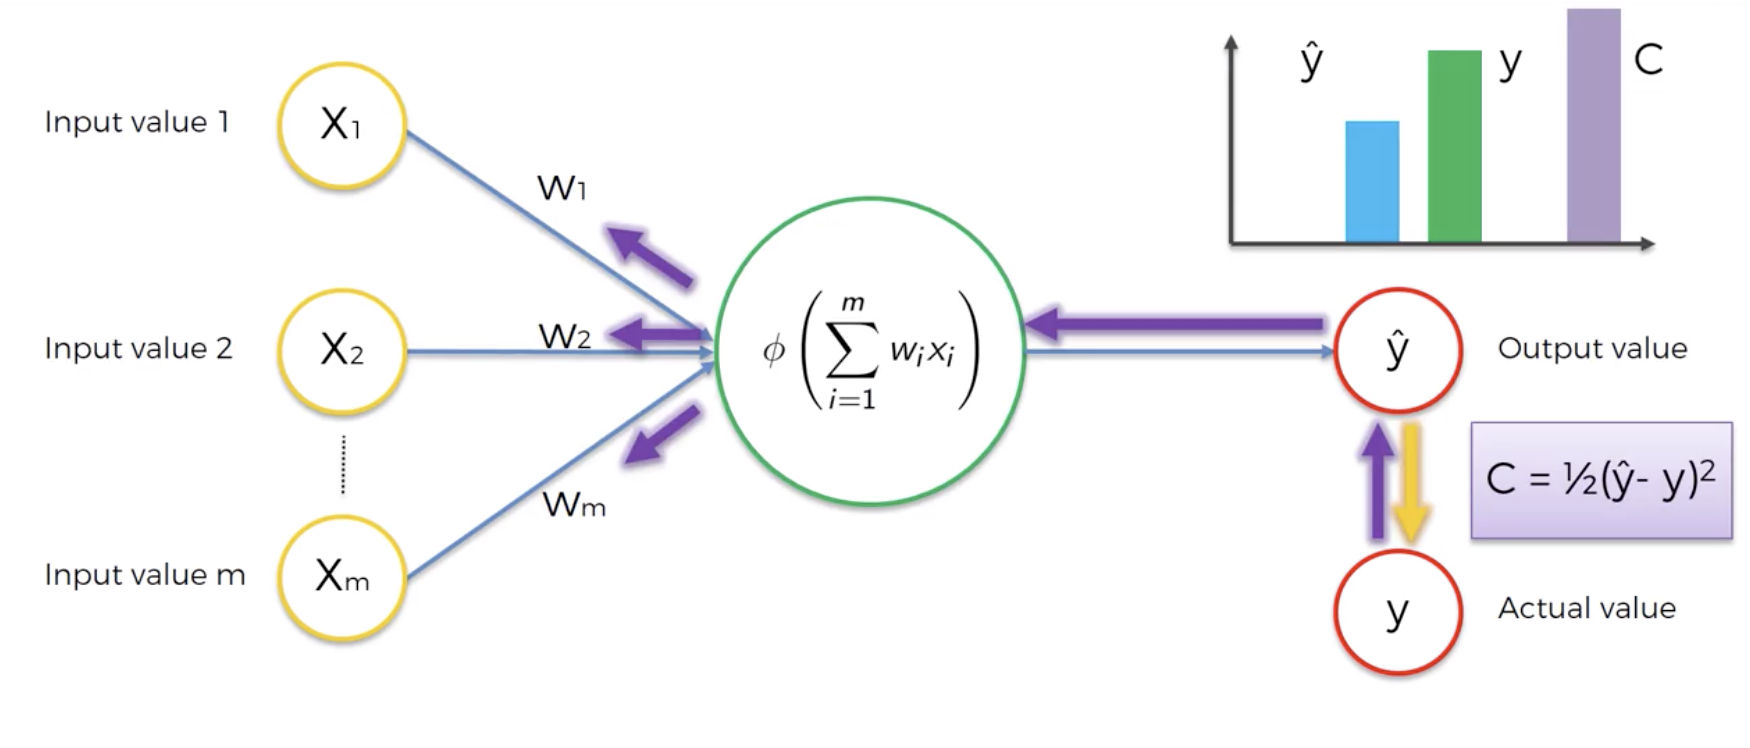



You have to train your model until the cost function is near to 0. 

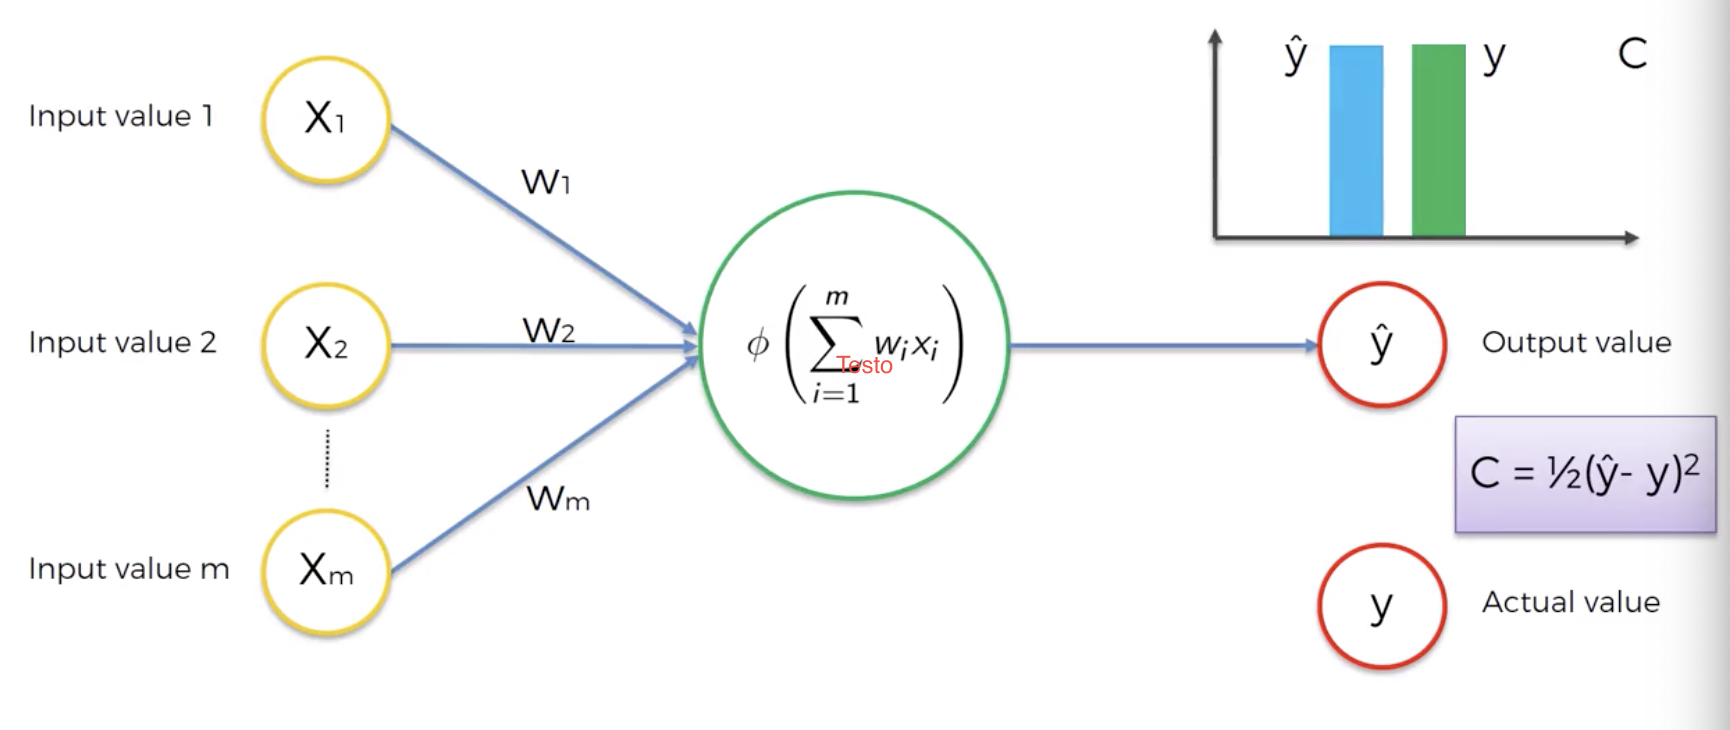


You have to do this process for each row in your data. Each iteration adjust the value of w1, w2, w3 ... 


# Gradient Descent
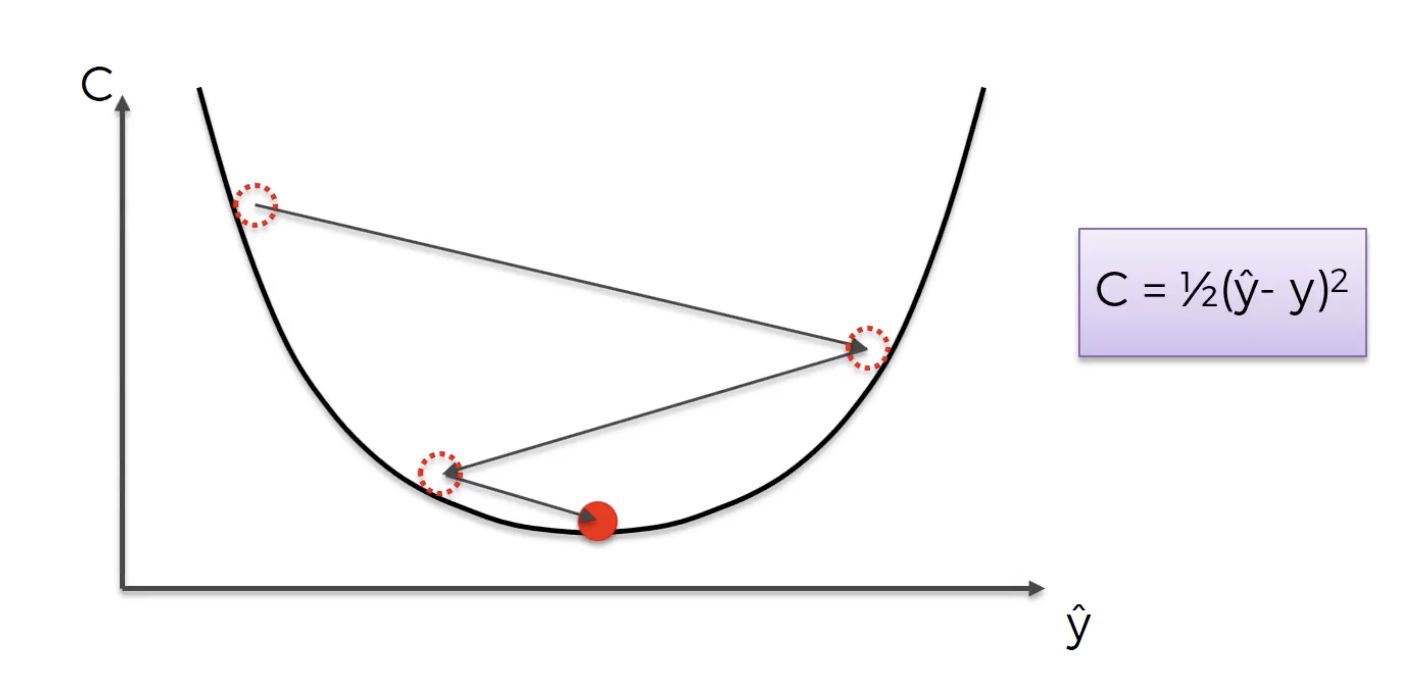
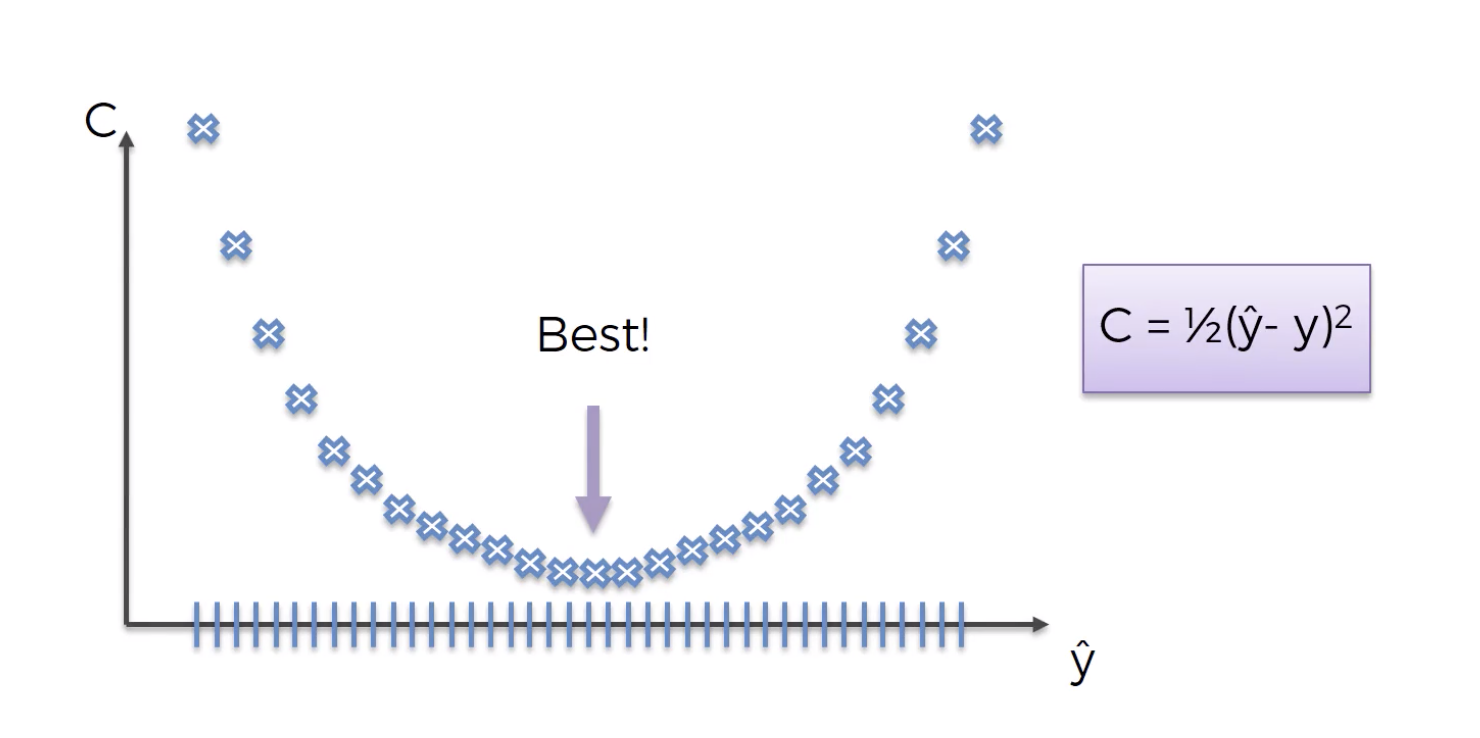




We should try each combination of weights to find the minimum... this is impossible. 


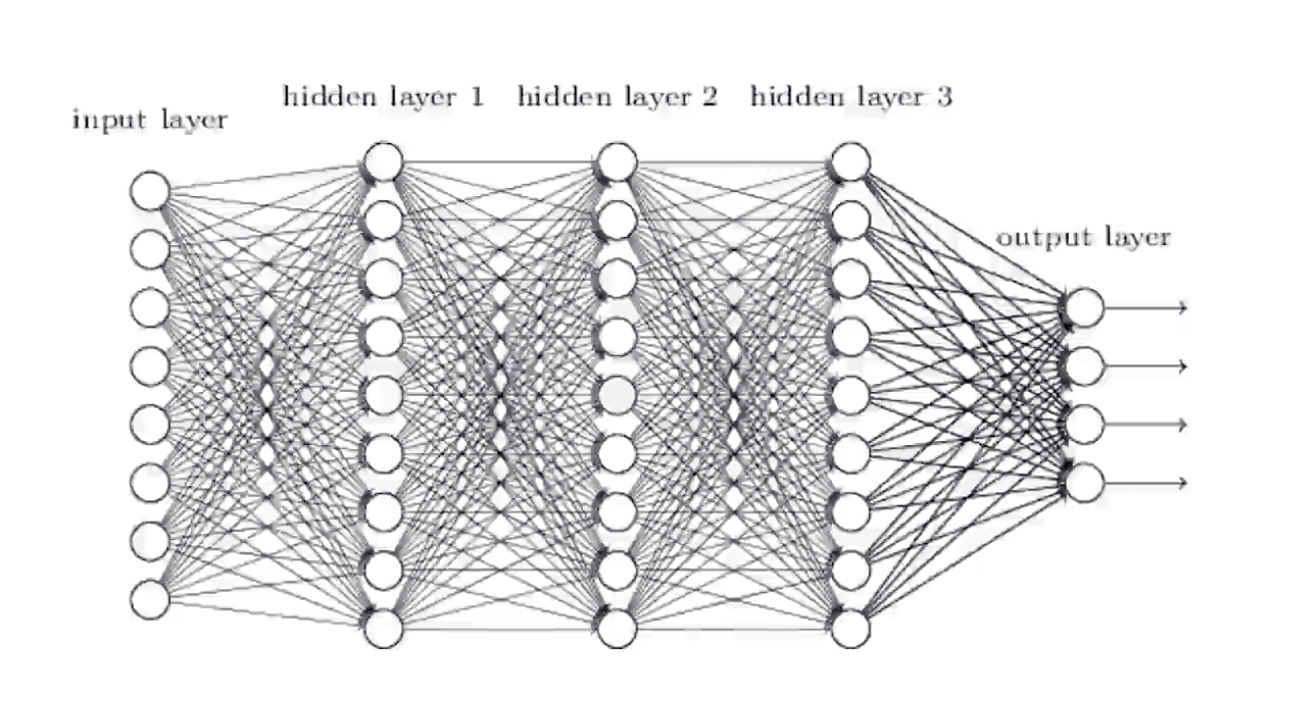


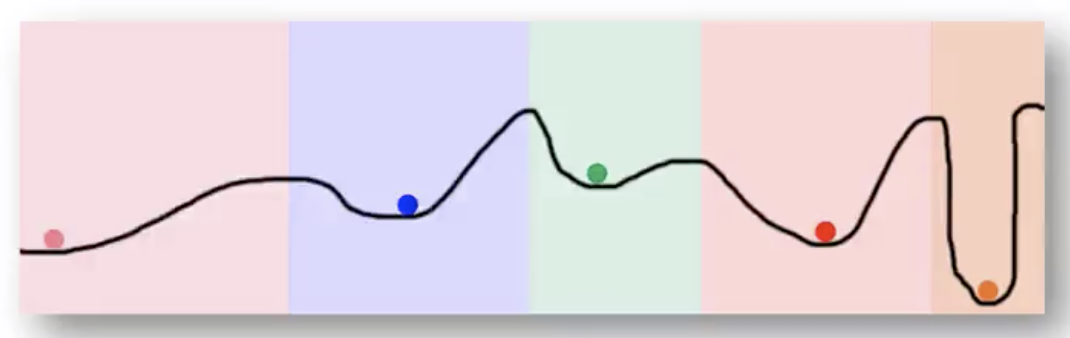# Stochastic Gradient Descent

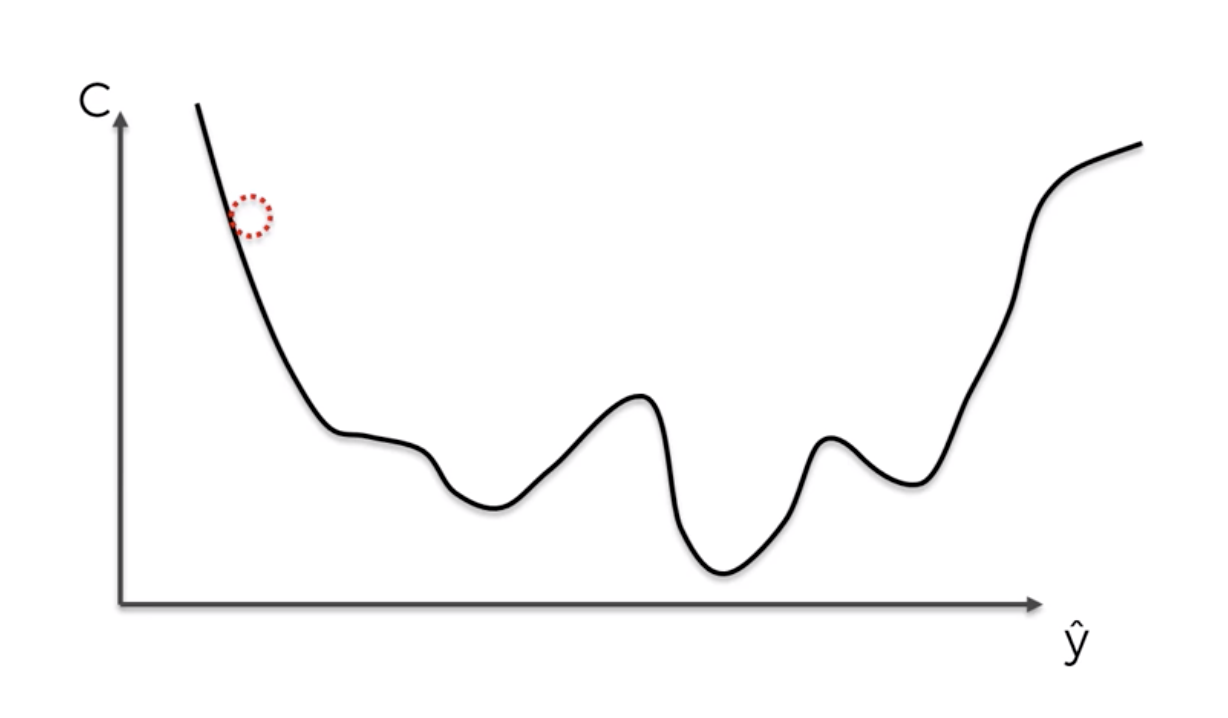
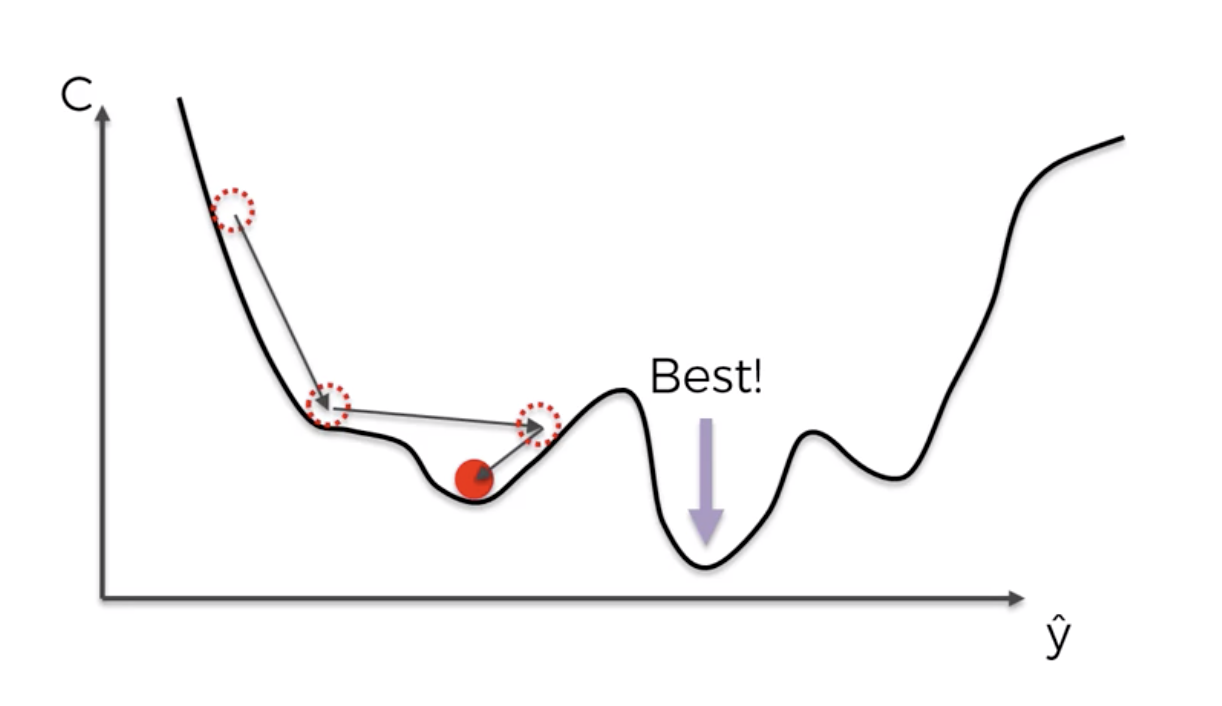
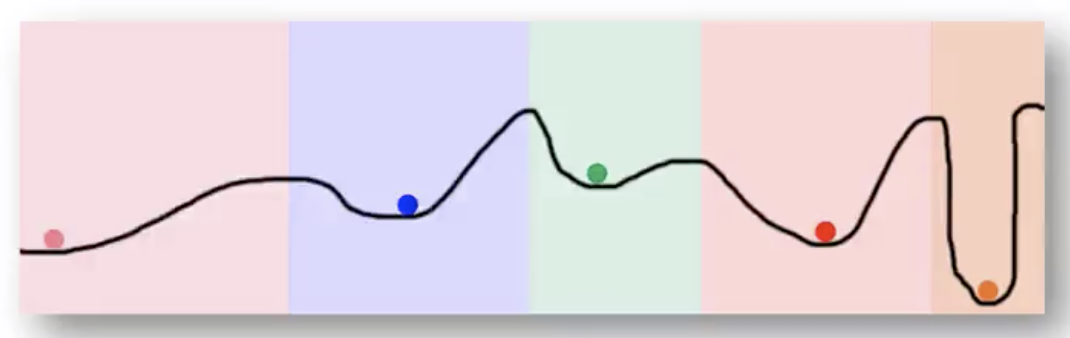



# Build a Neural Network

We want to predict which customers will leave the bank. So it is a classification problem. 

- Install keras library ---> conda install -c conda-forge keras  ( or ---> pip install keras )
- Install Theano library ---> pip install theano
- Install Tensorflow library ---> pip install tensorflow

conda update --all

Theano  is an open source numerical computation library. With Theano you can run your code on GPU or CPU. 

TensorFlow is an open source numerical computation library that can run really fast computations. 

Theese two libraries are used mostly for research and developing purposes in deep learning fields. 

Keras is an amazing library to build deep neural networks model in a very few lines of code. Keras is based in Theano and Tensorflow. 

Take a look to 4_Churn_Modeling.csv file.

## Part 1 - Data preprocessing 
Prepare data correctly. 

In [2]:
# Classification template
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Importing the dataset
dataset = pd.read_csv('4_Churn_Modelling.csv')
dataset   # information of customers of the bank

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


#### **CreditScore**: have impact to the decision to stay or leave the bank
#### **Geography**: people tent to have same bank of their neighbors or friends.
#### **Gender**: perhaps man has more tendency to leave than woman or viceversa. 
#### **Age**: younger people have more probabilities to leave a bank than old people that have more stability. 
#### **Tenure**: according to your tenure you are more likely to stay or leave a bank
#### **Balance**: a person with 0 balance are more likely to leave than a person with an high balance 
#### **NumOfproducts**: we cannot know if it has an impact but we can use it as well 
#### **Has Credit Card**: we might expect that a person with the credit card is more likely to stay 
#### **Is Active member**: customer active member is more likely to stay in a bank 
#### **Estimated Salary**: customer with an high salary is more likely to stay in a bank 
#### **Exited**: is the class, 0 if a person left the bank, 1 otherwise


In [4]:
X = dataset.iloc[:, 3:13].values   # upperbound is not included
y = dataset.iloc[:, 13].values    # class

In [5]:
df_X = pd.DataFrame(X)
df_X

,0,1,2,3,4,5,6,7,8,9
0,619,France,Female,42,2,0,1,1,1,101349
1,608,Spain,Female,41,1,83807.9,1,0,1,112543
2,502,France,Female,42,8,159661,3,1,0,113932
3,699,France,Female,39,1,0,2,0,0,93826.6
4,850,Spain,Female,43,2,125511,1,1,1,79084.1
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0,2,1,0,96270.6
9996,516,France,Male,35,10,57369.6,1,1,1,101700
9997,709,France,Female,36,7,0,1,0,1,42085.6
9998,772,Germany,Male,42,3,75075.3,2,1,0,92888.5


In [6]:
pd.DataFrame(y).shape

(10000, 1)

Before splitting the dataset in training set and test set we have to transform the categorical data in numerical data 

In [7]:
# Encoding categorical data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [8]:
labelencoder_X_1 = LabelEncoder()
X[:, 1] = labelencoder_X_1.fit_transform(X[:, 1])
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,619,0,Female,42,2,0,1,1,1,101349
1,608,2,Female,41,1,83807.9,1,0,1,112543
2,502,0,Female,42,8,159661,3,1,0,113932
3,699,0,Female,39,1,0,2,0,0,93826.6
4,850,2,Female,43,2,125511,1,1,1,79084.1
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,Male,39,5,0,2,1,0,96270.6
9996,516,0,Male,35,10,57369.6,1,1,1,101700
9997,709,0,Female,36,7,0,1,0,1,42085.6
9998,772,1,Male,42,3,75075.3,2,1,0,92888.5


In [9]:
labelencoder_X_2 = LabelEncoder()
X[:, 2] = labelencoder_X_2.fit_transform(X[:, 2])
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,619,0,0,42,2,0,1,1,1,101349
1,608,2,0,41,1,83807.9,1,0,1,112543
2,502,0,0,42,8,159661,3,1,0,113932
3,699,0,0,39,1,0,2,0,0,93826.6
4,850,2,0,43,2,125511,1,1,1,79084.1
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0,2,1,0,96270.6
9996,516,0,1,35,10,57369.6,1,1,1,101700
9997,709,0,0,36,7,0,1,0,1,42085.6
9998,772,1,1,42,3,75075.3,2,1,0,92888.5


In [10]:
## is not necessary to do the same for Male and Female because is a binary value
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [11]:
X_test.shape

(2000, 10)

In [12]:
# Feature Scaling
# Feature scaling is a method used to normalize the range of independent variables or features of data. 
# In data processing, it is also known as data normalization and is generally performed during 
# the data preprocessing step.
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [13]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9
0,0.169582,1.519198,-1.091687,-0.464608,0.006661,-1.215717,0.809503,0.642595,-1.032270,1.106432
1,-2.304559,0.313126,0.916013,0.301026,-1.377440,-0.006312,-0.921591,0.642595,0.968738,-0.748664
2,-1.191196,-0.892945,-1.091687,-0.943129,-1.031415,0.579935,-0.921591,0.642595,-1.032270,1.485335
3,0.035566,1.519198,0.916013,0.109617,0.006661,0.473128,-0.921591,0.642595,-1.032270,1.276528
4,2.056114,1.519198,-1.091687,1.736588,1.044737,0.810193,0.809503,0.642595,0.968738,0.558378
...,...,...,...,...,...,...,...,...,...,...
7995,-0.582970,0.313126,-1.091687,-0.656016,-0.339364,0.703104,0.809503,0.642595,0.968738,1.091330
7996,1.478815,1.519198,-1.091687,-1.613058,-0.339364,0.613060,-0.921591,0.642595,0.968738,0.131760
7997,0.901515,-0.892945,0.916013,-0.368904,0.006661,1.361474,0.809503,0.642595,-1.032270,1.412320
7998,-0.624205,1.519198,-1.091687,-0.081791,1.390762,-1.215717,0.809503,0.642595,0.968738,0.844321


## Now our data are well preprocessed!  Let's import keras libraries 

In [14]:
import keras # using tendorflow backend

In [15]:
from keras.models import Sequential
from keras.layers import Dense

Let's build a classifier. Our ANN is a Sequential of layers 
The model needs to know what input shape it should expect. For this reason, the first layer in a Sequential model (and only the first, because following layers can do automatic shape inference) needs to receive information about its input shape. 

In [16]:
X_train.shape

(8000, 10)

#### Let's create a model that has 1 input layer of 10 neurons and 2 hidden layers, of 8 and 5 neurons, 1 output layer with a single neuron.

<img src="images/nn3.jpg">

#### classifier.add(Dense( 
- units = NUMBER OF NODES in the hiddel layeris empirical, but you can start using the mean between the number of nodes of the input layer and the number of nodes of the output layer.,
- init = how the initial weights are initialized, 'uniform' initialize randomly
- activation = what activation function I want to use in the hidden layer 
- input_dim = number of nodes in input 
-  ... ))

#### Number of nodes in the hidden layer is empirical, but you can start using the mean between the number of nodes of the input layer and the number of nodes of the output layer. 



Number of hidden layers? 

The better way is experimenting the parameter tuning


In [17]:
classifier = Sequential()

# adding the first hidden layer 
classifier.add(Dense(units = 8, activation = 'relu', input_dim = 10 ))

# adding the second hidden layer 
classifier.add(Dense(units = 5, activation = 'relu'))

# adding the output layer 
classifier.add(Dense(units = 1, activation = 'sigmoid')) # sigmoid 

# KEEP IN MIND : for more than 2 categories you'll use SOFTMAX function

classifier.compile ( 
- optimizer = 'adam' is the most efficient for the gradient descent parameter 
- loss = sperify the loss function 'binary_crossentropy'
- metrics = [] a list of metric  ['accuracy']
- )

In [18]:
# compile the ANN
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy' , metrics = ['accuracy'] )  

classifier.fit(
- Training set of values = X_train, 
- Training set of class = y_train, 
- batch_size = The batch size is a number of samples processed before the model is updated. . The size of a batch must be more than or equal to one and less than or equal to the number of samples in the training dataset
- epoch = The number of epochs is the number of complete passes through the training dataset
- )

In [19]:
classifier.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 8)                 88        
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 45        
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 6         
Total params: 139
Trainable params: 139
Non-trainable params: 0
_________________________________________________________________


If we look carefully the number of parameters of the output layer is equal to 6 even if the number of neurons in the last hidden layer is just 5. This is why we must always remember that biased netwok has also a connection with an extra bias node and, consequently, a bias weight. In this case, this explains why the output layer has 6 parameters to train.
<img src="images/bias_weight.webp" width=40%>

In [20]:
# Fitting the ANN with the training set 
h = classifier.fit(X_train, y_train, validation_split=0.33, batch_size = 8, epochs = 100) 

Epoch 1/100
670/670 [==============================] - 1s 983us/step - loss: 0.6521 - accuracy: 0.6867 - val_loss: 0.5635 - val_accuracy: 0.7940
Epoch 2/100
670/670 [==============================] - 0s 624us/step - loss: 0.5099 - accuracy: 0.8003 - val_loss: 0.4908 - val_accuracy: 0.7982
Epoch 3/100
670/670 [==============================] - 0s 630us/step - loss: 0.4464 - accuracy: 0.8184 - val_loss: 0.4504 - val_accuracy: 0.8054
Epoch 4/100
670/670 [==============================] - 0s 659us/step - loss: 0.4147 - accuracy: 0.8222 - val_loss: 0.4261 - val_accuracy: 0.8194
Epoch 5/100
670/670 [==============================] - 0s 649us/step - loss: 0.3934 - accuracy: 0.8349 - val_loss: 0.4099 - val_accuracy: 0.8311
Epoch 6/100
670/670 [==============================] - 0s 619us/step - loss: 0.3805 - accuracy: 0.8403 - val_loss: 0.3989 - val_accuracy: 0.8315
Epoch 7/100
670/670 [==============================] - 0s 601us/step - loss: 0.3730 - accuracy: 0.8429 - val_loss: 0.3936 - val_ac

In [21]:
y_pred  = classifier.predict(X_test)
pd.DataFrame(y_pred)

,0
0,0.273477
1,0.225063
2,0.154270
3,0.038111
4,0.065784
...,...
1995,0.009185
1996,0.037585
1997,0.142025
1998,0.189087


# Confusion matrix 

In [22]:
y_pred_bool = (y_pred > 0.3)
pd.DataFrame(y_pred_bool)

,0
0,False
1,False
2,False
3,False
4,False
...,...
1995,False
1996,False
1997,False
1998,False


In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_bool)
cm

array([[1386,  209],
       [ 146,  259]], dtype=int64)

# Accuracy 
The percentage of corrected predictions over all the predictions can be computed as the sum of correct classifications over the total of samples


In [24]:
(cm[0][0] + cm[1][1]) / 2000

0.8225

which alternatively means computing the *accuracy_score(predictions, ground-truth)*

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred_bool, y_test)

0.8225

## Plotting training data

In [26]:
import matplotlib.pyplot as plt

# list all data in history
print(h.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


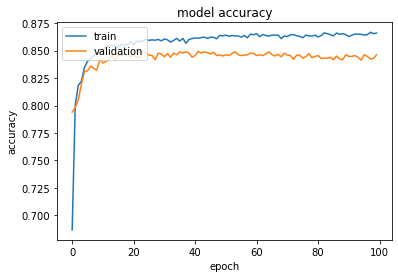

In [27]:
# summarize history for accuracy
plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

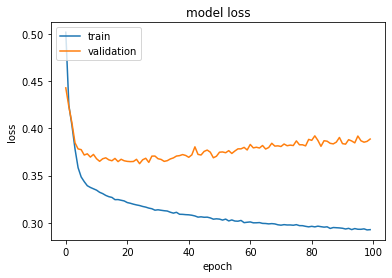

In [27]:
# summarize history for loss
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## How do we test for a specific sample?


<img src="images/22.png" width=50%>
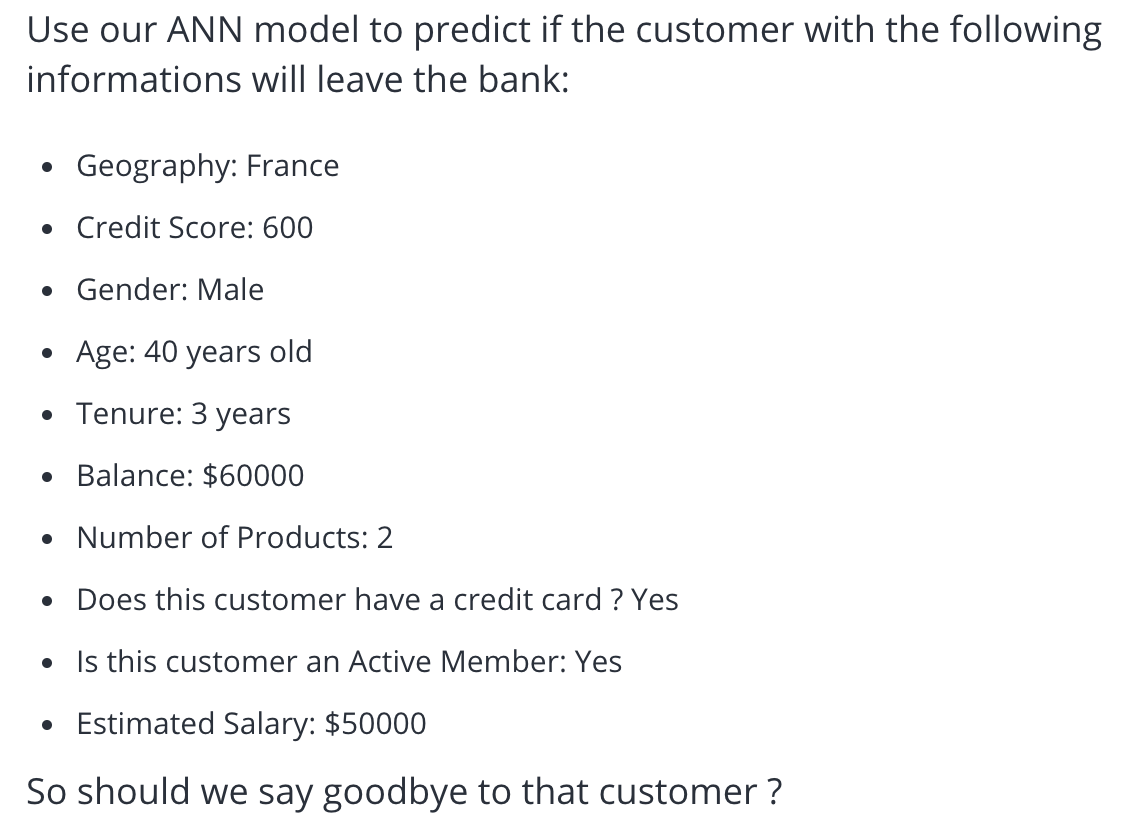

# Solution 

In [28]:
pd.DataFrame(X)   # the dataset processed 

,0,1,2,3,4,5,6,7,8,9
0,619,0,0,42,2,0,1,1,1,101349
1,608,2,0,41,1,83807.9,1,0,1,112543
2,502,0,0,42,8,159661,3,1,0,113932
3,699,0,0,39,1,0,2,0,0,93826.6
4,850,2,0,43,2,125511,1,1,1,79084.1
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0,2,1,0,96270.6
9996,516,0,1,35,10,57369.6,1,1,1,101700
9997,709,0,0,36,7,0,1,0,1,42085.6
9998,772,1,1,42,3,75075.3,2,1,0,92888.5


In [29]:
pd.DataFrame(dataset)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [30]:
#my observation has to be in horizondal vector 
# we need also to encode the variables 

In [31]:
sample = sc.transform(np.array([[ 600, 0, 1, 40, 3 , 60000, 2 , 1, 1, 50000 ]]))
new_prediction = classifier.predict(sample) 
new_prediction

array([[0.02058366]], dtype=float32)

In [32]:
new_prediction > 0.3

array([[False]])

In [33]:
## The customers doesn't leave the bank 